# Sentiment prediction of kindle reviews

##### Simple workflow
1. [X] Preprocessing and cleaning the dataset
2. [X] Train Test split
3. [X] Word embeddings
4. [X] Training
5. [X] Testing

### Preprossing the data

In [169]:
import pandas as pd
review = pd.read_csv('all_kindle_review.csv')
review.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [170]:
#We only require rating and review text for this specific model so we will drop everything else
review = review[['reviewText', 'rating']]
review.head() 

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


In [171]:
review.shape

(12000, 2)

In [172]:
review.isnull().sum() #checking for null values

reviewText    0
rating        0
dtype: int64

In [173]:
review['rating'].unique()

array([3, 5, 4, 2, 1], dtype=int64)

In [174]:
review['rating'].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

In [175]:
review['rating'] = review['rating'].apply(lambda x:0 if x<3 else 1) #Positive review is 1, negative is 0

In [176]:
review['reviewText'] = review['reviewText'].str.lower()

In [177]:
type(review)

pandas.core.frame.DataFrame

In [178]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
from nltk.corpus import stopwords
lemmatizer = WordNetLemmatizer()
corpus = []

for i in range(0, len(review)):
    X = re.sub('^[a-zA-Z0-9]', ' ', review['reviewText'][i])
    X = X.lower()
    X = X.split()
    X = [lemmatizer.lemmatize(word) for word in X if not word in set(stopwords.words('english'))]
    X = ' '.join(X)
    corpus.append(X)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\goggl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [179]:
type(corpus)

list

### Train Test Split

In [180]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    corpus,
    review['rating'],
    random_state=67,
    test_size=0.20
)

### Word embeddings

In [181]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [182]:
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer()

In [183]:
x_train_bow = bow.fit_transform(x_train).toarray()
x_test_bow = bow.transform(x_test).toarray()

In [184]:
x_train_tf = tfidf.fit_transform(x_train).toarray()
x_test_tf = tfidf.transform(x_test).toarray()

### Traing Naive Bayes and Logistic Regressing models

In [185]:
from sklearn.naive_bayes import GaussianNB
model_nb_tf = GaussianNB().fit(x_train_tf, y_train)
model_nb_bow = GaussianNB().fit(x_train_bow, y_train)

In [186]:
from sklearn.linear_model import LogisticRegression
model_lr_idf = LogisticRegression().fit(x_train_tf, y_train)
model_lr_bow = LogisticRegression().fit(x_train_bow, y_train)

### Testing

#### Naive Bayes model

In [187]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [188]:
y_pred_nb_1 = model_nb_tf.predict(x_test_tf)

In [189]:
accuracy_score(y_pred=y_pred_nb_1, y_true= y_test)

0.6033333333333334

In [190]:
print(confusion_matrix(y_pred=y_pred_nb_1, y_true=y_test))

[[637 159]
 [793 811]]


In [191]:
print(classification_report(y_pred=y_pred_nb_1, y_true=y_test))

              precision    recall  f1-score   support

           0       0.45      0.80      0.57       796
           1       0.84      0.51      0.63      1604

    accuracy                           0.60      2400
   macro avg       0.64      0.65      0.60      2400
weighted avg       0.71      0.60      0.61      2400



In [192]:
y_pred_nb_2 = model_nb_bow.predict(x_test_bow)

In [193]:
accuracy_score(y_pred_nb_2, y_test)

0.5941666666666666

In [194]:
print('Confusion marix is:\n',confusion_matrix(y_pred_nb_1, y_test))
print('Classification report is:\n',  classification_report(y_pred_nb_1, y_test))

Confusion marix is:
 [[637 793]
 [159 811]]
Classification report is:
               precision    recall  f1-score   support

           0       0.80      0.45      0.57      1430
           1       0.51      0.84      0.63       970

    accuracy                           0.60      2400
   macro avg       0.65      0.64      0.60      2400
weighted avg       0.68      0.60      0.60      2400



#### Linear Regression

In [195]:
y_pred_lr_1 = model_lr_idf.predict(x_test_tf)

In [196]:
accuracy_score(y_pred=y_pred_lr_1, y_true=y_test)

0.8475

In [197]:
print('Confusion marix is:\n',confusion_matrix(y_pred_lr_1, y_test))
print('Classification report is:\n',  classification_report(y_pred_lr_1, y_test))

Confusion marix is:
 [[ 531  101]
 [ 265 1503]]
Classification report is:
               precision    recall  f1-score   support

           0       0.67      0.84      0.74       632
           1       0.94      0.85      0.89      1768

    accuracy                           0.85      2400
   macro avg       0.80      0.85      0.82      2400
weighted avg       0.87      0.85      0.85      2400



In [198]:
y_pred_lr_2 = model_lr_bow.predict(x_test_bow)

In [199]:
accuracy_score(y_pred_lr_2, y_test)

0.83875

In [200]:
print('Confusion marix is:\n',confusion_matrix(y_pred_lr_2, y_test))
print('Classification report is:\n',  classification_report(y_pred_lr_2, y_test))

Confusion marix is:
 [[ 577  168]
 [ 219 1436]]
Classification report is:
               precision    recall  f1-score   support

           0       0.72      0.77      0.75       745
           1       0.90      0.87      0.88      1655

    accuracy                           0.84      2400
   macro avg       0.81      0.82      0.82      2400
weighted avg       0.84      0.84      0.84      2400



### Visual representation using word cloud

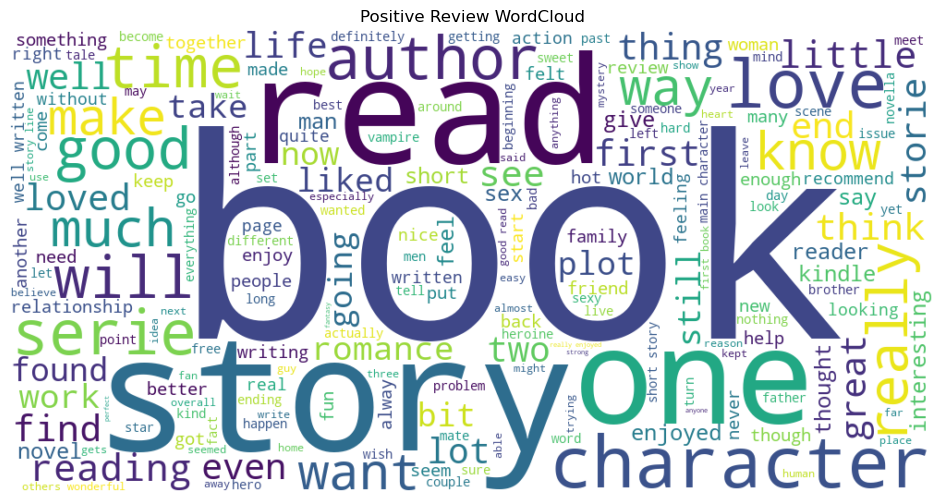

In [201]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Positive reviews
positive_reviews = " ".join(review[review['rating'] == 1]['reviewText'].astype(str))

positive_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Review WordCloud")
plt.show()

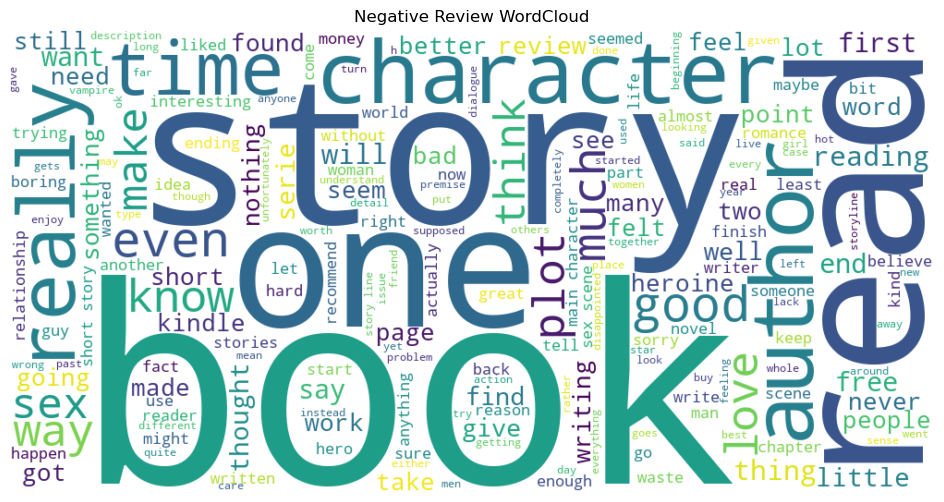

In [202]:
# Negative reviews
negative_reviews = " ".join(review[review['rating'] == 0]['reviewText'].astype(str))

negative_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Review WordCloud")
plt.show()